<h1 align="center" style="margin-bottom: 20px;">Data Analysis - Cash and Carry brand CAC1</h1>


### READ THIS FIRST:
This notebook is the first of three notebooks created for this project. The other two notebooks are not included in the Repository as their content is more about the creation of a recommender system and less about the Data Analysis.

This notebook is part of a project for the course of my Master in Data Science and Advanced Analytics at Nova IMS University. It was originally part of an actual Business Case, so it included real data from a real Cash and Carry brand. As this data is confidential and was only used in the university course, the data shown in this notebook has been anonymized, including dummy values and non-identifiable and randomly created IDs. The name of the Cash and Carry brand is also kept anonymous, so the name used in this notebook, CAC1, is a fictional name with no connection to any real brand intended.

The original notebook included some more aspects that have been excluded from this notebook, as they needed actual understandable data (like real ZIP-Codes) to show useful results. Examples of the excluded parts are: (1) A differentiation between Client Types (Hostel/Restaurant Clients vs Other), (2) Grouping ZIP-Codes by region (North, Center, South), (3) Adding an advanced approach to match each product with a distinct price, leading to visualizations about revenue, divided by for example customer types or regions.

This whole project was made by a group of three students in total, including myself. We had a very dynamic duty distribution, everybody participated in all parts of the project. However, this first notebook including the Data Preprocessing, Feature Engineering, Data Analysis and Data Visualization was mostly done by myself, while the other parts of the project not included in this repository were done mostly by the other participants of the group.


# Table of contents<a id='toc0_'></a>    
- [Importing Important Libraries](#toc3_)    
- [Importing Datasets](#toc4_)    
    - [Clients Dataset](#toc4_1_1_)    
    - [Transactions Dataset](#toc4_1_2_)    
    - [Products Dataset](#toc4_1_3_)    
- [Business Understanding and Objectives](#toc5_)    
  - [CAC1’s Market Segments](#toc5_1_)
  - [Machine Learning Objectives](#toc5_2_)    
  - [Business Objectives](#toc5_3_)    
- [Clients Dataset](#toc6_)    
  - [Data Preprocessing](#toc6_1_)    
    - [Set Index, Constant Features and Duplicates](#toc6_1_1_)    
      - [Set Index](#toc6_1_1_1_)    
      - [Constant Features](#toc6_1_1_2_)    
      - [Duplicates](#toc6_1_1_3_)    
    - [Missing Values](#toc6_1_2_)    
    - [Data Types](#toc6_1_3_)    
    - [Inconsistencies](#toc6_1_4_)    
      - [ZIP - Code](#toc6_1_4_1_)    
    - [Visualizations](#toc6_1_5_)    
- [Products Dataset](#toc7_)    
  - [Data Preprocessing](#toc7_1_)    
    - [Set Index, Constant Features, Duplicates and Missing Values](#toc7_1_1_)    
      - [Set Index](#toc7_1_1_1_)    
      - [Constant Features](#toc7_1_1_2_)    
      - [Missing Values](#toc7_1_1_3_)    
      - [Duplicates](#toc7_1_1_4_)    
  - [Data Exploration](#toc7_2_)    
- [Transactions Dataset](#toc8_)    
  - [Data Preprocessing](#toc8_1_)    
    - [Duplicates and Missing Values](#toc8_1_1_)    
      - [Duplicates](#toc8_1_1_1_)    
      - [Missing Values](#toc8_1_1_2_)    
- [Feature Engineering](#toc9_)    
- [Visualizations](#toc10_)       
- [Data Exportation](#toc11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc2_1_'></a>[Notebook Objective](#toc0_)

This notebook is dedicated to performing Exploratory Data Analysis (EDA) on all the datasets provided for the development of the recommender system. We will use basic statistical methods and visualization tools to gain insights into the data, identify patterns, and uncover potential improvements for building a more effective and targeted recommendation engine.

# <a id='toc3_'></a>[Importing Important Libraries](#toc0_)

In [107]:
# Packages
import os
import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
from math import ceil
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

#pip install requests
import requests

# Omit Warnings
import warnings
warnings.filterwarnings("ignore")

# Auxiliar Colors
coolwarm_colors = [
    '#3b4cc0', '#4f6cc0', '#628ccc', '#7aa6d9', '#99c1e2',
    '#e1dad6', '#f4b5a7', '#e68a75', '#d35b5b', '#b40426'
]

# <a id='toc4_'></a>[Importing Datasets](#toc0_)

### <a id='toc4_1_1_'></a>[Clients Dataset](#toc0_)

In [108]:
clients_df = pd.read_csv('data/Clients Data.csv', sep=';')
clients_df.head()

,Client ID,ZIP Code,ID Client Type
0,500000001,10001,NaN
1,500000002,10002,NaN
2,500000003,10003,NaN
3,500000004,10004,Client Type 1
4,500000005,10005,NaN


### <a id='toc4_1_2_'></a>[Transactions Dataset](#toc0_)

In [109]:
trans_df = pd.read_csv('data/Transactions Data.csv', sep=';')
trans_df.head()

,Date,Client ID,ID Product
0,2022-01-02,500000277,300001
1,2022-01-02,500000277,300002
2,2022-01-02,500000277,300003
3,2022-01-02,500000277,300004
4,2022-01-02,500000277,300005


### <a id='toc4_1_3_'></a>[Products Dataset](#toc0_)

In [110]:
prod_df = pd.read_csv('data/Products Data.csv', sep=';')
prod_df.head(5)

,ID Product,Product Description,ID Product Category
0,300001,Description 1,Category 1
1,300002,Description 2,Category 2
2,300003,Description 3,Category 2
3,300004,Description 4,Category 3
4,300005,Description 5,Category 3


# <a id='toc5_'></a>[Business Understanding and Objectives](#toc0_)

- We were given three distinct datasets, each offering critical information for the development of a recommender system tailored to CAC1's business needs:

    1. **Clients Dataset** – Contains client-specific information, including a unique ID, Zip Code, and Type of Client.

    2. **Products Dataset** – Provides details about products, including product ID, description, and category.

    3. **Transactions Dataset** – Records all purchases made throughout 2022, linking client IDs to the products they bought.

These datasets form the backbone of our analysis and allow us to model customer behavior, preferences, and purchase patterns.

## <a id='toc5_2_'></a>[Machine Learning Objectives](#toc0_)
Our machine learning model must:

- Adapt to seasonality, understanding that demand for certain products changes throughout the year (e.g., ice cream in summer, soups in winter).

- Enrich data using external sources or engineered features to improve recommendation accuracy (e.g., mapping ZIP codes to regions or including weather patterns for seasonal products).

## <a id='toc5_3_'></a>[Business Objectives](#toc0_)
The recommender system aims to:

- Increase CAC1's share of wallet by encouraging existing customers to buy more – either new categories or higher volumes.

- Provide actionable insights to CAC1’s marketing and sales teams, such as identifying dormant clients, cross-selling opportunities, and product bundling suggestions.

- Support strategic decisions, including personalized promotions or tailored communication per client type and region.

# <a id='toc6_'></a>[Clients Dataset](#toc0_)

In [111]:
clients_df.shape

(6462, 3)

In [112]:
# Display top 5 rows
clients_df.head(5)

,Client ID,ZIP Code,ID Client Type
0,500000001,10001,NaN
1,500000002,10002,NaN
2,500000003,10003,NaN
3,500000004,10004,Client Type 1
4,500000005,10005,NaN


In [113]:
# Display last 5 rows
clients_df.tail(5)

,Client ID,ZIP Code,ID Client Type
6457,500006458,10182,NaN
6458,500006459,10252,NaN
6459,500006460,10004,NaN
6460,500006461,10012,NaN
6461,500006462,10051,NaN


In [114]:
# Checking the data types of the variables of the training dataset and if there are any missing values
clients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6462 entries, 0 to 6461
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Client ID       6462 non-null   int64
 1   ZIP Code        6462 non-null   int64
 2   ID Client Type  680 non-null    str  
dtypes: int64(2), str(1)
memory usage: 151.6 KB


**Conclusion:** With this information, we can conclude that only the 'Client Type' column has missing values.

In [115]:
# Getting the main descriptive statistics only for the numerical variables

clients_df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Client ID,6462.0,5.000032e+08,1865.56,500000001.0,5.000016e+08,500003231.5,5.000048e+08,500006462.0
ZIP Code,6462.0,1.003583e+04,47.90,10001.0,1.000800e+04,10015.0,1.003700e+04,10261.0


In [116]:
# Getting the main descriptive statistics for the remaining cathegorical variables

clients_df.describe(include = ['object']).T

,count,unique,top,freq
ID Client Type,680,26,Client Type 1,231


In [117]:
clients_df['ID Client Type'].unique()

<StringArray>
[             nan,  'Client Type 1',  'Client Type 2',  'Client Type 3',
  'Client Type 4',  'Client Type 5',  'Client Type 6',  'Client Type 7',
  'Client Type 8',  'Client Type 9', 'Client Type 10', 'Client Type 11',
 'Client Type 12', 'Client Type 13', 'Client Type 14', 'Client Type 15',
 'Client Type 16', 'Client Type 17', 'Client Type 18', 'Client Type 19',
 'Client Type 20', 'Client Type 21', 'Client Type 22', 'Client Type 23',
 'Client Type 24', 'Client Type 25', 'Client Type 26']
Length: 27, dtype: str

**Conclusion:** Excluding the NaNs, we can conclude that there are 26 different types of customers.

In [118]:
clients_df['ZIP Code'].unique()

array([10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009,
       10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018,
       10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027,
       10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036,
       10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045,
       10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054,
       10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063,
       10064, 10065, 10066, 10067, 10068, 10069, 10070, 10071, 10072,
       10073, 10074, 10075, 10076, 10077, 10078, 10079, 10080, 10081,
       10082, 10083, 10084, 10085, 10086, 10087, 10088, 10089, 10090,
       10091, 10092, 10093, 10094, 10095, 10096, 10097, 10098, 10099,
       10100, 10101, 10102, 10103, 10104, 10105, 10106, 10107, 10108,
       10109, 10110, 10111, 10112, 10113, 10114, 10115, 10116, 10117,
       10118, 10119, 10120, 10121, 10122, 10123, 10124, 10125, 10126,
       10127, 10128,

## <a id='toc6_1_'></a>[Data Preprocessing](#toc0_)

### <a id='toc6_1_1_'></a>[Set Index, Constant Features and Duplicates](#toc0_)

#### <a id='toc6_1_1_1_'></a>[Set Index](#toc0_)

- Let's check if 'Client ID' is appropriate for index:

In [119]:
clients_df['Client ID'].describe()

count    6.462000e+03
mean     5.000032e+08
std      1.865563e+03
min      5.000000e+08
25%      5.000016e+08
50%      5.000032e+08
75%      5.000048e+08
max      5.000065e+08
Name: Client ID, dtype: float64

In [120]:
clients_df['Client ID'].isna().sum()

np.int64(0)

**Conclusion:** No missing values.

In [121]:
clients_df['Client ID'].duplicated().sum()

np.int64(0)

**Conclusion:** No duplicates.

In [122]:
clients_df_index = clients_df.set_index("Client ID")
clients_df_index.head()

,ZIP Code,ID Client Type
Client ID,,
500000001,10001,NaN
500000002,10002,NaN
500000003,10003,NaN
500000004,10004,Client Type 1
500000005,10005,NaN


#### <a id='toc6_1_1_2_'></a>[Constant Features](#toc0_)

In [123]:
variances = clients_df_index.var(numeric_only=True)
variances[variances == 0]

Series([], dtype: float64)

**Conclusion**: There are no constant features.

#### <a id='toc6_1_1_3_'></a>[Duplicates](#toc0_)

In [124]:
# Check for duplicated observations
clients_df_index.dropna().duplicated().sum()

np.int64(408)

**Conclusion:** Excluding the Nan's, there are a lot of duplicates, let's analyse them. 

In [125]:
duplicates = clients_df_index.dropna()
duplicates[duplicates.duplicated(keep=False)]

,ZIP Code,ID Client Type
Client ID,,
500000004,10004,Client Type 1
500000030,10017,Client Type 1
500000041,10008,Client Type 1
500000047,10020,Client Type 2
500000163,10029,Client Type 2
...,...,...
500006442,10008,Client Type 1
500006443,10008,Client Type 1
500006445,10094,Client Type 1


In [126]:
duplicates[duplicates['ZIP Code'] == 10004]

,ZIP Code,ID Client Type
Client ID,,
500000004,10004,Client Type 1
500000863,10004,Client Type 1
500001805,10004,Client Type 1
500001996,10004,Client Type 2
500002869,10004,Client Type 6
500003253,10004,Client Type 3
500003256,10004,Client Type 6
500003892,10004,Client Type 2
500004022,10004,Client Type 1


**Conclusion:** For example, the ZIP Code 10004 corresponds to a big city, a city with numerous businesses in the multiple sectors. Considering that each case corresponds to a unique Client ID, we will keep all duplicates for now, since a city can have more than one business.

In [127]:
# First, find all duplicated rows based on Client ID, ZIP Code, and Client Type
duplicated_rows = clients_df_index[clients_df_index.duplicated(subset=['ZIP Code', 'ID Client Type'], keep=False)]

# Then, count how many duplicates exist per Client Type
duplicates_by_type = duplicated_rows['ID Client Type'].value_counts().sort_index()

duplicates_by_type

ID Client Type
Client Type 1     207
Client Type 10      2
Client Type 11      2
Client Type 14      2
Client Type 2     116
Client Type 20      2
Client Type 23      2
Client Type 24      2
Client Type 3      10
Client Type 4      45
Client Type 5       4
Client Type 6     111
Client Type 7      11
Client Type 8       3
Client Type 9       5
Name: count, dtype: int64

**Conclusion:** We can observe that the highest number of duplicate entries occurs within the categories of Client Type 1, Client Type 2 and Client Type 6. These duplicates should not necessarily be seen as actual data duplication, but rather as an indication of the areas where CAC1 has a stronger business presence.

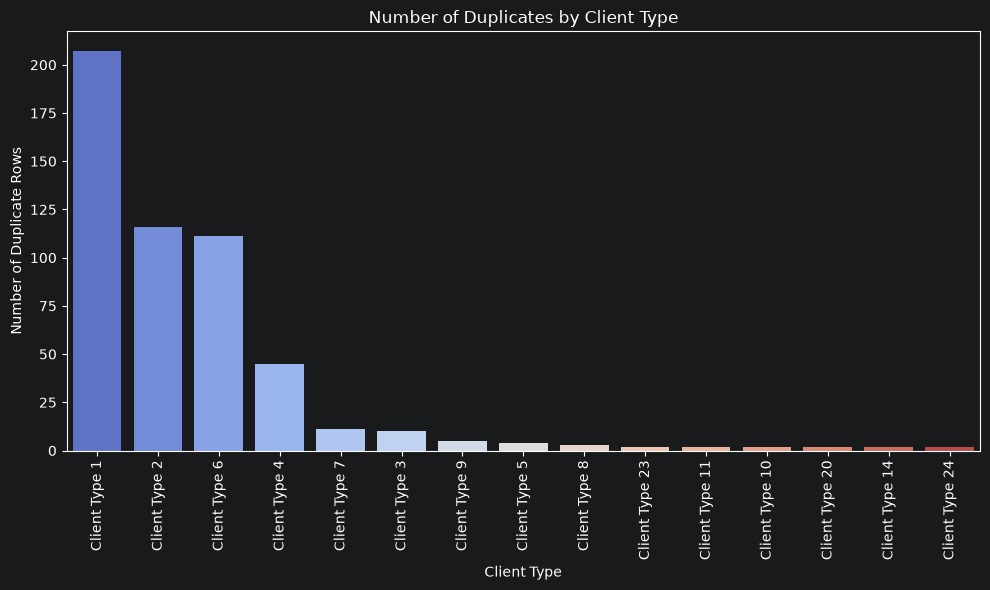

In [128]:
# Sort duplicates by count in descending order
duplicates_by_type_sorted = duplicates_by_type.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=duplicates_by_type_sorted.index.astype(str), y=duplicates_by_type_sorted.values, palette="coolwarm")
plt.title('Number of Duplicates by Client Type')
plt.xlabel('Client Type')
plt.ylabel('Number of Duplicate Rows')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### <a id='toc6_1_2_'></a>[Missing Values](#toc0_)

In [129]:
clients_df_treat_missing = clients_df_index.copy()

In [130]:
# Calculate the percentage of missing values in each column
perc_missing_values = (clients_df_treat_missing.isna().sum() / len(clients_df_treat_missing) * 100).round(2)
perc_missing_values[perc_missing_values > 0].sort_values(ascending=False)

ID Client Type    89.48
dtype: float64

In [131]:
clients_df_treat_missing["ID Client Type"].value_counts(dropna=False, normalize=True).sort_index() * 100

ID Client Type
Client Type 1      3.574745
Client Type 10     0.061900
Client Type 11     0.154751
Client Type 12     0.015475
Client Type 13     0.015475
Client Type 14     0.108326
Client Type 15     0.015475
Client Type 16     0.061900
Client Type 17     0.030950
Client Type 18     0.015475
Client Type 19     0.015475
Client Type 2      2.151037
Client Type 20     0.030950
Client Type 21     0.015475
Client Type 22     0.030950
Client Type 23     0.046425
Client Type 24     0.030950
Client Type 25     0.015475
Client Type 26     0.015475
Client Type 3      0.526153
Client Type 4      0.882080
Client Type 5      0.123801
Client Type 6      2.089136
Client Type 7      0.232126
Client Type 8      0.108326
Client Type 9      0.154751
NaN               89.476942
Name: proportion, dtype: float64

**Conclusion:** As we can conclude, most values in the Client Type ID column are NaN. However, since this column may contain valuable information, we will attempt to impute the missing values. To do this, we will cross-reference the data with the other available datasets and perform the imputation only for active clients — that is, those who appear in the transactions dataset.

In [132]:
# Reset index to access 'Client ID' as a column (if needed)
clients_df_reset = clients_df_treat_missing.reset_index()

# Extract unique Client IDs
client_ids_clients = set(clients_df_reset['Client ID'].unique())
client_ids_transactions = set(trans_df['Client ID'].unique())

# IDs present in both datasets
common_ids = client_ids_clients.intersection(client_ids_transactions)

# IDs present only in clients (no transactions)
missing_ids = client_ids_clients.difference(client_ids_transactions)

# Counts
total_clients = len(client_ids_clients)
with_transactions = len(common_ids)
without_transactions = len(missing_ids)

# Percentages
percent_with = with_transactions / total_clients * 100
percent_without = without_transactions / total_clients * 100
percent_match_clients = with_transactions / total_clients * 100
percent_match_transactions = with_transactions / len(client_ids_transactions) * 100

# Output
print(f"Total clients: {total_clients}")
print(f"Clients WITH transactions: {with_transactions} ({percent_with:.2f}%)")
print(f"Clients WITHOUT transactions: {without_transactions} ({percent_without:.2f}%)")
print(f"Match rate relative to 'clients': {percent_match_clients:.2f}%")
print(f"Match rate relative to 'transactions': {percent_match_transactions:.2f}%")

Total clients: 6462
Clients WITH transactions: 1529 (23.66%)
Clients WITHOUT transactions: 4933 (76.34%)
Match rate relative to 'clients': 23.66%
Match rate relative to 'transactions': 100.00%


**Conclusion:** Out of a total of 6,462 clients, only 1,529 (23.66%) have made transactions, while the remaining 4,933 clients (76.34%) have not made any transactions. This indicates a significant portion of clients has not engaged with the business in terms of transactions.

The match rate relative to the total number of clients is 23.66%, which means that nearly a quarter of the clients are responsible for all transactions. On the other hand, the match rate relative to transactions is 100%, as all transactions can be linked back to the 1,529 active clients.

In [133]:
# Show only customers with transactions
customers_with_transactions = clients_df_reset[clients_df_reset['Client ID'].isin(common_ids)]

# Display the first few rows
customers_with_transactions

,Client ID,ZIP Code,ID Client Type
3,500000004,10004,Client Type 1
9,500000010,10008,NaN
29,500000030,10017,Client Type 1
46,500000047,10020,Client Type 2
91,500000092,10004,NaN
...,...,...,...
6457,500006458,10182,NaN
6458,500006459,10252,NaN
6459,500006460,10004,NaN
6460,500006461,10012,NaN


In [134]:
# Merge the customers with transactions and transactions dataset on 'Client ID'
merged_df = pd.merge(customers_with_transactions, trans_df, on='Client ID', how='inner')

# Display the first few rows of the merged dataset
merged_df

,Client ID,ZIP Code,ID Client Type,Date,ID Product
0,500000004,10004,Client Type 1,2022-01-23,300359
1,500000004,10004,Client Type 1,2022-01-23,300828
2,500000004,10004,Client Type 1,2022-01-23,300829
3,500000004,10004,Client Type 1,2022-01-23,300830
4,500000004,10004,Client Type 1,2022-01-25,300359
...,...,...,...,...,...
884094,500006462,10051,NaN,2022-12-30,300710
884095,500006462,10051,NaN,2022-12-30,300722
884096,500006462,10051,NaN,2022-12-30,300308
884097,500006462,10051,NaN,2022-12-30,301727


In [135]:
# Merge the merged dataset with prod_df on 'Product ID'
final_merged_df = pd.merge(merged_df, prod_df, on='ID Product', how='inner')

# Display the first few rows of the final merged dataset
final_merged_df

,Client ID,ZIP Code,ID Client Type,Date,ID Product,Product Description,ID Product Category
0,500000004,10004,Client Type 1,2022-01-23,300359,Description 359,Category 2
1,500000004,10004,Client Type 1,2022-01-23,300828,Description 828,Category 94
2,500000004,10004,Client Type 1,2022-01-23,300829,Description 829,Category 94
3,500000004,10004,Client Type 1,2022-01-23,300830,Description 830,Category 94
4,500000004,10004,Client Type 1,2022-01-25,300359,Description 359,Category 2
...,...,...,...,...,...,...,...
884094,500006462,10051,NaN,2022-12-30,300710,Description 710,Category 156
884095,500006462,10051,NaN,2022-12-30,300722,Description 722,Category 156
884096,500006462,10051,NaN,2022-12-30,300308,Description 308,Category 57
884097,500006462,10051,NaN,2022-12-30,301727,Description 1727,Category 13


In [136]:
# Frequency encoding for categorical variables
# Encoding 'ID Product Category'
product_category_frequency = final_merged_df['ID Product Category'].value_counts().to_dict()
final_merged_df['ID Product Category Encoded'] = final_merged_df['ID Product Category'].map(product_category_frequency)

# Drop rows where 'ID Client Type' is not NaN for training
train_data = final_merged_df.dropna(subset=['ID Client Type'])

# Separate independent (X) and dependent (y) variables for training
X_train = train_data[['ZIP Code', 'ID Product Category Encoded']]  # Use both ZIP Code and encoded product category
y_train = train_data['ID Client Type']  # The dependent variable we want to predict

# Separate the rows where 'ID Client Type' is missing
missing_data = final_merged_df[final_merged_df['ID Client Type'].isna()]

# Independent variables for the missing data (without 'ID Client Type' to predict)
X_missing = missing_data[['ZIP Code', 'ID Product Category Encoded']]  # Use both ZIP Code and encoded product category

In [137]:
# Train the decision tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [138]:
# Predict the 'ID Client Type' for the rows with missing values
predicted_client_type = model.predict(X_missing)

In [139]:
# Add the predictions back to the missing data rows
missing_data['ID Client Type'] = predicted_client_type

In [140]:
# Now, replace the missing values in the original DataFrame with the predicted values
final_merged_df.update(missing_data)

# Display the updated DataFrame
final_merged_df['ID Client Type'].value_counts()

ID Client Type
Client Type 1     440311
Client Type 2     231212
Client Type 6      96904
Client Type 4      50169
Client Type 3      31738
Client Type 7       7291
Client Type 11      5465
Client Type 9       3907
Client Type 13      2431
Client Type 14      2390
Client Type 16      2104
Client Type 19      1824
Client Type 5       1821
Client Type 8       1448
Client Type 10      1442
Client Type 23      1303
Client Type 17      1239
Client Type 15       449
Client Type 21       334
Client Type 18       212
Client Type 24        62
Client Type 20        43
Name: count, dtype: int64

In [141]:
final_merged_df

,Client ID,ZIP Code,ID Client Type,Date,ID Product,Product Description,ID Product Category,ID Product Category Encoded
0,500000004,10004,Client Type 1,2022-01-23,300359,Description 359,Category 2,48627
1,500000004,10004,Client Type 1,2022-01-23,300828,Description 828,Category 94,6293
2,500000004,10004,Client Type 1,2022-01-23,300829,Description 829,Category 94,6293
3,500000004,10004,Client Type 1,2022-01-23,300830,Description 830,Category 94,6293
4,500000004,10004,Client Type 1,2022-01-25,300359,Description 359,Category 2,48627
...,...,...,...,...,...,...,...,...
884094,500006462,10051,Client Type 6,2022-12-30,300710,Description 710,Category 156,2077
884095,500006462,10051,Client Type 6,2022-12-30,300722,Description 722,Category 156,2077
884096,500006462,10051,Client Type 6,2022-12-30,300308,Description 308,Category 57,13239
884097,500006462,10051,Client Type 6,2022-12-30,301727,Description 1727,Category 13,32396


**Conclusion:** Now that we have resolved the issue with the NaNs, we will go back to extracting the columns of interest, in this case, 'Client ID', 'ID Client Type', and 'Zip Code', to continue our analysis at the Client level.

In [142]:
clients_df_treat_missing_final = final_merged_df[['Client ID', 'ZIP Code', 'ID Client Type']]

- Now, since we have multiple duplicate entries due to transactions, we will remove all duplicates based on Client ID.

In [143]:
clients_df_treat_missing_final = clients_df_treat_missing_final.drop_duplicates(subset='Client ID')
clients_df_treat_missing_final.set_index('Client ID', inplace=True)

In [144]:
# Check the percentage of missing values in the final DataFrame
perc_missing_values = (clients_df_treat_missing_final.isna().sum() / len(clients_df_treat_missing_final) * 100).round(2)
perc_missing_values[perc_missing_values > 0].sort_values(ascending=False)

Series([], dtype: float64)

### <a id='toc6_1_3_'></a>[Data Types](#toc0_)

In [145]:
clients_df_adjust_dtypes = clients_df_treat_missing_final.copy()

In [146]:
clients_df_adjust_dtypes.dtypes

ZIP Code          int64
ID Client Type      str
dtype: object

**Conclusion:** Everthing is on the right data type. 

### <a id='toc6_1_4_'></a>[Inconsistencies](#toc0_)

In [147]:
clients_df_inconsistencies = clients_df_adjust_dtypes.copy()

#### <a id='toc6_1_4_1_'></a>[ZIP - Code](#toc0_)

In [148]:
# Convert 'ZIP Code' column to string
clients_df_inconsistencies['ZIP Code'] = clients_df_inconsistencies['ZIP Code'].astype(str)

# Function to check if the ZIP Code has exactly 5 digits
invalid_zip_codes = clients_df_inconsistencies[~clients_df_inconsistencies['ZIP Code'].str.match(r'^\d{5}$')]

# Display invalid entries
invalid_zip_codes

,ZIP Code,ID Client Type
Client ID,,


### <a id='toc6_1_5_'></a>[Visualizations](#toc0_)

In [149]:
clients_df_clean = clients_df_inconsistencies.copy()

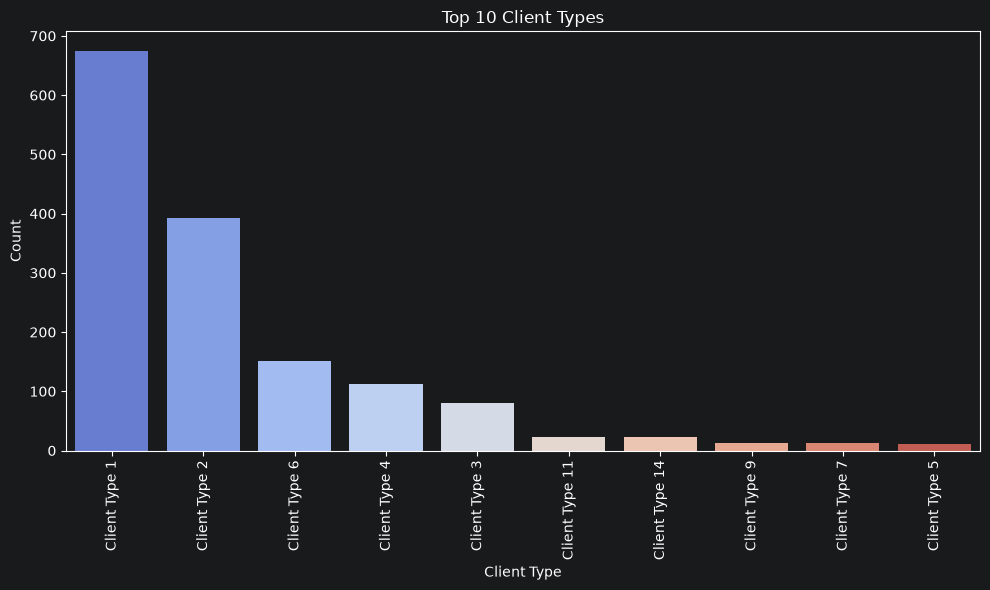

In [150]:
# Visualization of the top 10 Client Types
top_10_client_types = clients_df_clean['ID Client Type'].value_counts().head(10)

# Plotting the top 10 Client Types
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_client_types.index, y=top_10_client_types.values, palette= 'coolwarm')
plt.title('Top 10 Client Types')
plt.xlabel('Client Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

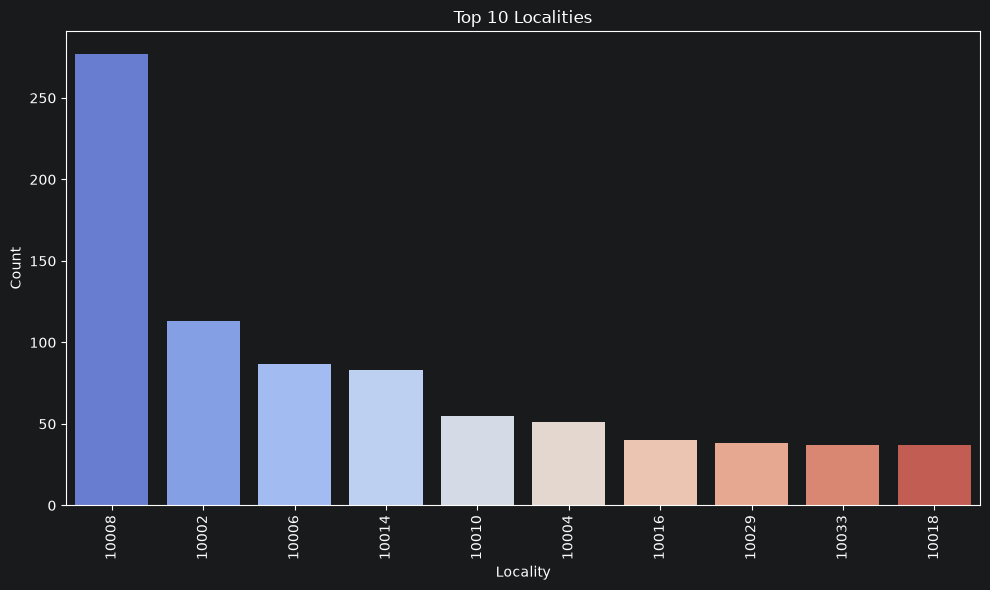

In [151]:
# Visualization of the top 10 Localities
top_10_zip_codes = clients_df_inconsistencies['ZIP Code'].value_counts().head(10)

# Plotting the top 10 ZIP Codes
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_zip_codes.index.astype(str), y=top_10_zip_codes.values, palette='coolwarm')
plt.title('Top 10 Localities')
plt.xlabel('Locality')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

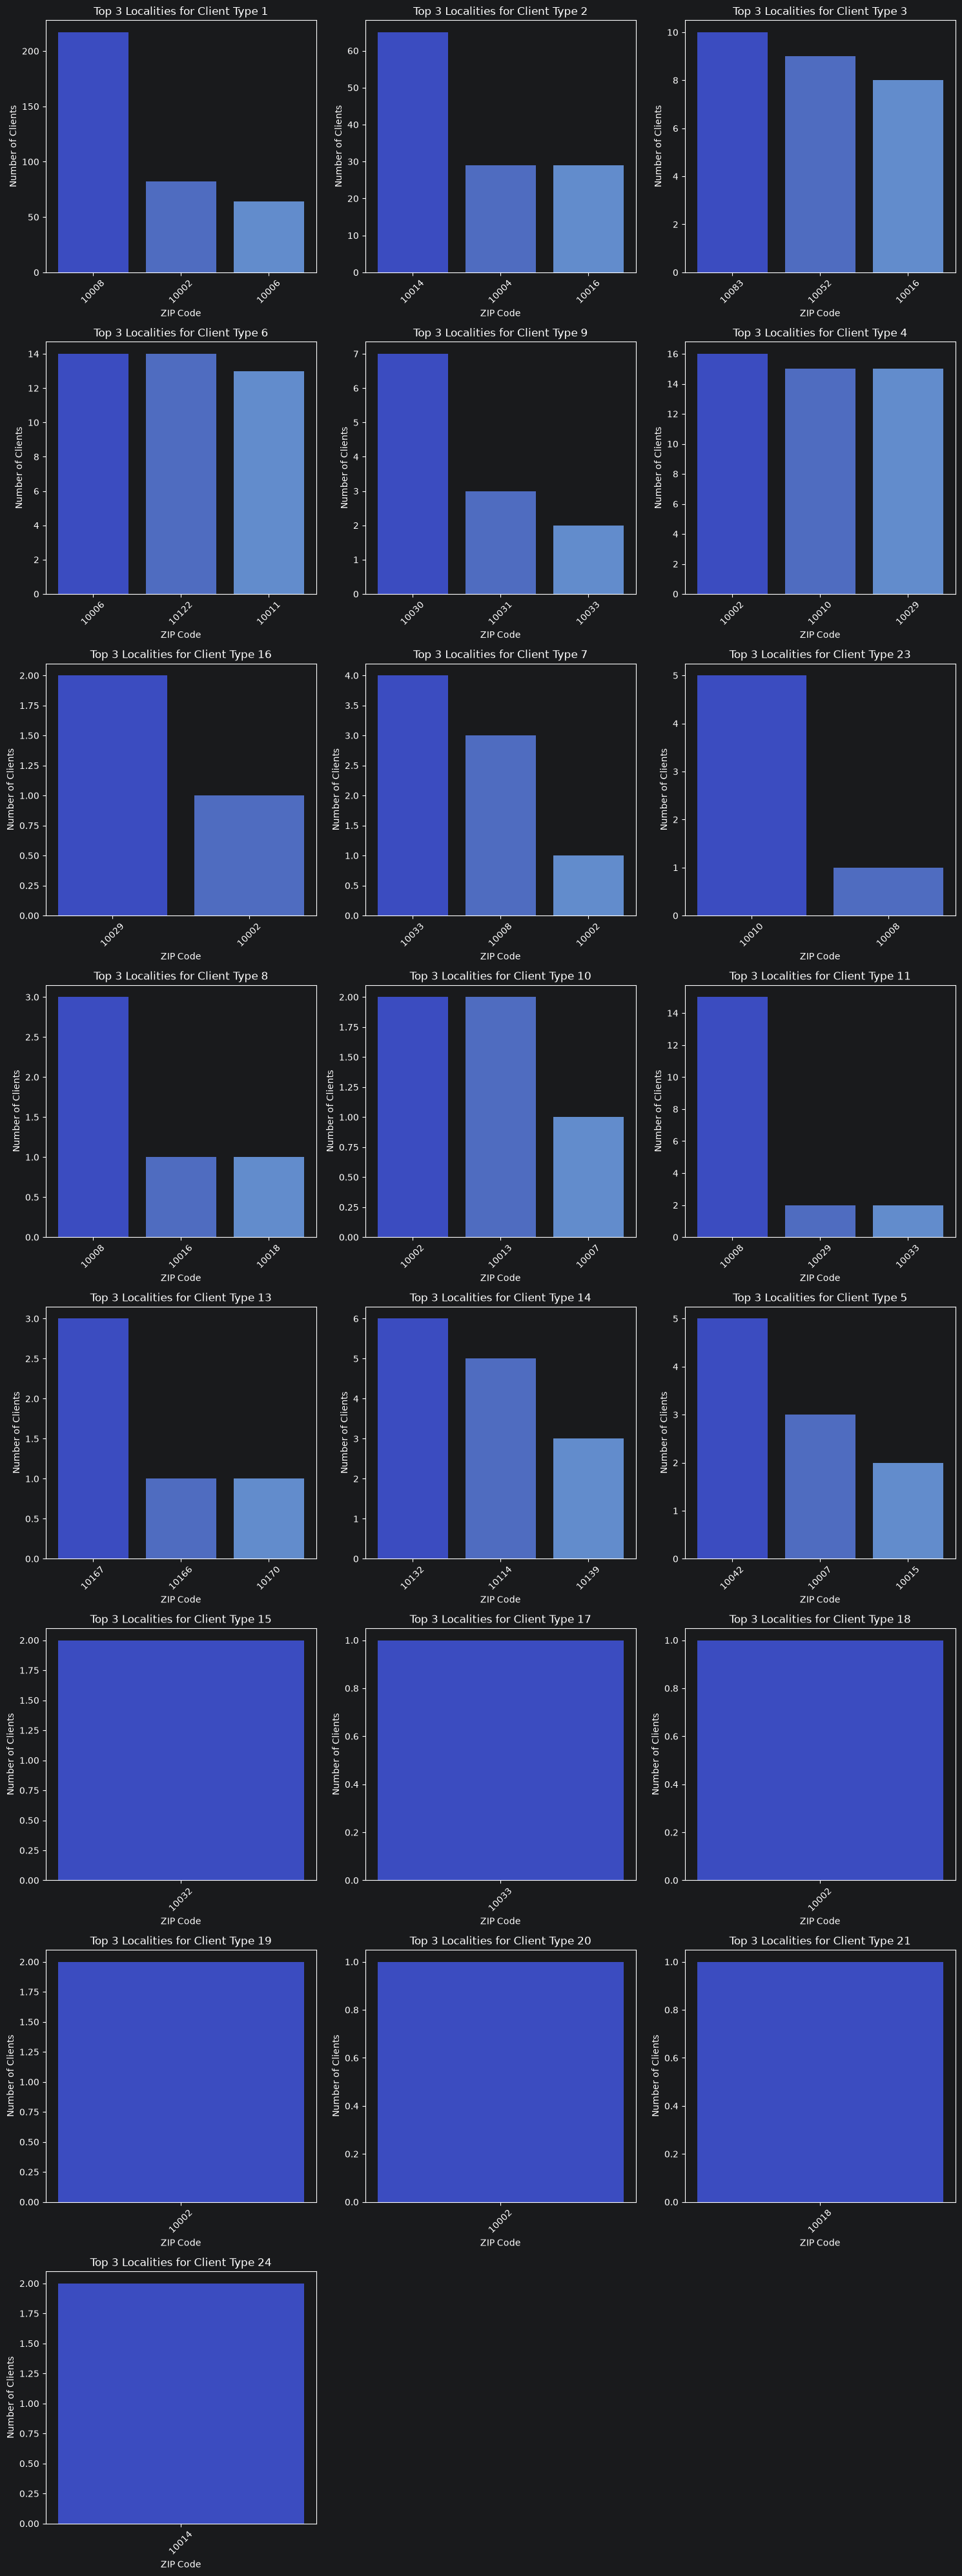

In [152]:
# Group by 'Client Type' and 'Locality', and count the clients
client_type_locality_counts = clients_df_clean.groupby(['ID Client Type', 'ZIP Code']).size().reset_index(name='Client Count')

# Define the unique client types
client_types = clients_df_clean['ID Client Type'].unique()

# Number of plots per row
num_columns = 3

# Calculate the number of rows needed for subplots
num_rows = (len(client_types) // num_columns) + (len(client_types) % num_columns > 0)

# Create subplots
fig, axes = plt.subplots(num_rows, num_columns, figsize=(15, num_rows * 5))

# Flatten axes for easier looping
axes = axes.flatten()

# Create a plot for each client type
for i, client_type in enumerate(client_types):
    # Filter the data for the current client type
    client_data = client_type_locality_counts[client_type_locality_counts['ID Client Type'] == client_type]
    
    # Get the top 3 localities based on the client count
    top_3_localities = client_data.nlargest(3, 'Client Count')
    
    # Plot the results
    axes[i].bar(top_3_localities['ZIP Code'], top_3_localities['Client Count'], color=coolwarm_colors)
    axes[i].set_title(f'Top 3 Localities for {client_type}')
    axes[i].set_xlabel('ZIP Code')
    axes[i].set_ylabel('Number of Clients')
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra axes if there are fewer client types than the number of subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

# <a id='toc7_'></a>[Products Dataset](#toc0_)

## <a id='toc7_1_'></a>[Data Preprocessing](#toc0_)

In [153]:
prod_df.shape

(4583, 3)

In [154]:
prod_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4583 entries, 0 to 4582
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID Product           4583 non-null   int64
 1   Product Description  4583 non-null   str  
 2   ID Product Category  4583 non-null   str  
dtypes: int64(1), str(2)
memory usage: 107.5 KB


In [155]:
prod_df.describe(include='all')

,ID Product,Product Description,ID Product Category
count,4583.000000,4583,4583
unique,NaN,4573,268
top,NaN,Description 330,Category 56
freq,NaN,2,175
mean,302292.000000,NaN,NaN
std,1323.142472,NaN,NaN
min,300001.000000,NaN,NaN
25%,301146.500000,NaN,NaN
50%,302292.000000,NaN,NaN
75%,303437.500000,NaN,NaN


**Conclusion:** At least one Product Description appears 2 times, has to be checked later.

### <a id='toc7_1_1_'></a>[Set Index, Constant Features, Duplicates and Missing Values](#toc0_)

#### <a id='toc7_1_1_1_'></a>[Set Index](#toc0_)

- Before converting 'ID Product', we have to check if it is in right format.

In [156]:
# Check for duplicated rows in this column
prod_df['ID Product'].duplicated().sum()

np.int64(0)

In [157]:
# Check for missing values in this column
prod_df["ID Product"].duplicated().sum()

np.int64(0)

In [158]:
# No problems, so we can convert the column to index
prod_df = prod_df.set_index("ID Product")
prod_df.head()

,Product Description,ID Product Category
ID Product,,
300001,Description 1,Category 1
300002,Description 2,Category 2
300003,Description 3,Category 2
300004,Description 4,Category 3
300005,Description 5,Category 3


#### <a id='toc7_1_1_2_'></a>[Constant Features](#toc0_)

In [159]:
variances = prod_df.var(numeric_only=True)
variances[variances == 0]

Series([], dtype: float64)

**Conclusion:** There are no constant features.

#### <a id='toc7_1_1_3_'></a>[Missing Values](#toc0_)

In [160]:
# Checking for missing values
prod_df.isna().sum()

Product Description    0
ID Product Category    0
dtype: int64

**Conclusion:** There are no missing values.

#### <a id='toc7_1_1_4_'></a>[Duplicates](#toc0_)

In [161]:
# Checking for duplicates
prod_df.duplicated().sum()

np.int64(10)

In [162]:
prod_df.loc[prod_df.duplicated()].head()

,Product Description,ID Product Category
ID Product,,
302855,Description 2467,Category 15
303360,Description 1677,Category 56
303591,Description 330,Category 71
303656,Description 1417,Category 42
304019,Description 3776,Category 44


**Conclusion:** As suspeceted, there are some rows with duplicates, 10 in total. From the previous command, we could see that Product Description 2467 is one of them, so we can have a look to understand better the problem.

In [163]:
prod_df[prod_df['Product Description'] == 'Description 2467']

,Product Description,ID Product Category
ID Product,,
302467,Description 2467,Category 15
302855,Description 2467,Category 15


- There are two products with different ID but same Description and Category.

In [164]:
# Check for all duplicated rows
product_duplicates = prod_df['Product Description'].value_counts()
product_duplicates = product_duplicates[product_duplicates > 1].index

filtered_df = prod_df[prod_df['Product Description'].isin(product_duplicates)]

filtered_df = filtered_df.sort_values(by='Product Description')

filtered_df

,Product Description,ID Product Category
ID Product,,
301383,Description 1383,Category 13
304320,Description 1383,Category 13
301417,Description 1417,Category 42
303656,Description 1417,Category 42
301493,Description 1493,Category 106
304286,Description 1493,Category 106
303360,Description 1677,Category 56
301677,Description 1677,Category 56
302467,Description 2467,Category 15


**Conclusion:** We see that in total, 10 product descriptions and Categories are duplicated each, however with different Product IDs. 

In [165]:
# Check if there are transactions for both of the products each
trans_df[trans_df['ID Product'] == 304440]

,Date,Client ID,ID Product
789950,2022-11-14,500006449,304440
796723,2022-11-18,500006451,304440
803662,2022-11-20,500006448,304440
803787,2022-11-20,500006461,304440


In [166]:
trans_df[trans_df['ID Product'] == 302981]

,Date,Client ID,ID Product
131615,2022-03-14,500005959,302981
153482,2022-03-23,500005958,302981


**Conclusion:** Since we find transactions for both products with different ID but same description each, it is likely that these might be different products but with same category, for example similar products by different brands or some slighty different details between the products that are not captured in the description. Since they have different Product IDs and there are transactions for both, we have to assume that these are different products in the system.

In [167]:
# We decide to add a _v1 and _v2 at the end of the products in order to differentiate them and have no duplicates in our data
prod_df_clean = prod_df.copy()

pair_index = [f" _v{i%2 + 1}" for i in range(len(filtered_df))]
filtered_df = filtered_df.copy()
filtered_df['Product Description'] = filtered_df['Product Description'].values + pair_index

prod_df_clean.update(filtered_df)

In [168]:
# Check if it worked
prod_df_clean.loc[filtered_df.index]

,Product Description,ID Product Category
ID Product,,
301383,Description 1383 _v1,Category 13
304320,Description 1383 _v2,Category 13
301417,Description 1417 _v1,Category 42
303656,Description 1417 _v2,Category 42
301493,Description 1493 _v1,Category 106
304286,Description 1493 _v2,Category 106
303360,Description 1677 _v1,Category 56
301677,Description 1677 _v2,Category 56
302467,Description 2467 _v1,Category 15


In [169]:
# Check if rest of rows are not affected
prod_df_clean.head(5)

,Product Description,ID Product Category
ID Product,,
300001,Description 1,Category 1
300002,Description 2,Category 2
300003,Description 3,Category 2
300004,Description 4,Category 3
300005,Description 5,Category 3


In [170]:
# Checking again for duplicates
prod_df_clean.duplicated().sum()

np.int64(0)

## <a id='toc7_2_'></a>[Data Exploration](#toc0_)

In [171]:
prod_df_clean

,Product Description,ID Product Category
ID Product,,
300001,Description 1,Category 1
300002,Description 2,Category 2
300003,Description 3,Category 2
300004,Description 4,Category 3
300005,Description 5,Category 3
...,...,...
304579,Description 4569,Category 74
304580,Description 4570,Category 53
304581,Description 4571,Category 28


In [172]:
# Get value counts of each product category
prod_df_clean['ID Product Category'].value_counts().head(20)

ID Product Category
Category 56     175
Category 15     172
Category 13     159
Category 57     148
Category 3      133
Category 142    131
Category 2      113
Category 27     100
Category 146     88
Category 11      84
Category 135     83
Category 186     76
Category 104     66
Category 154     63
Category 24      62
Category 47      60
Category 77      60
Category 119     60
Category 113     52
Category 101     48
Name: count, dtype: int64

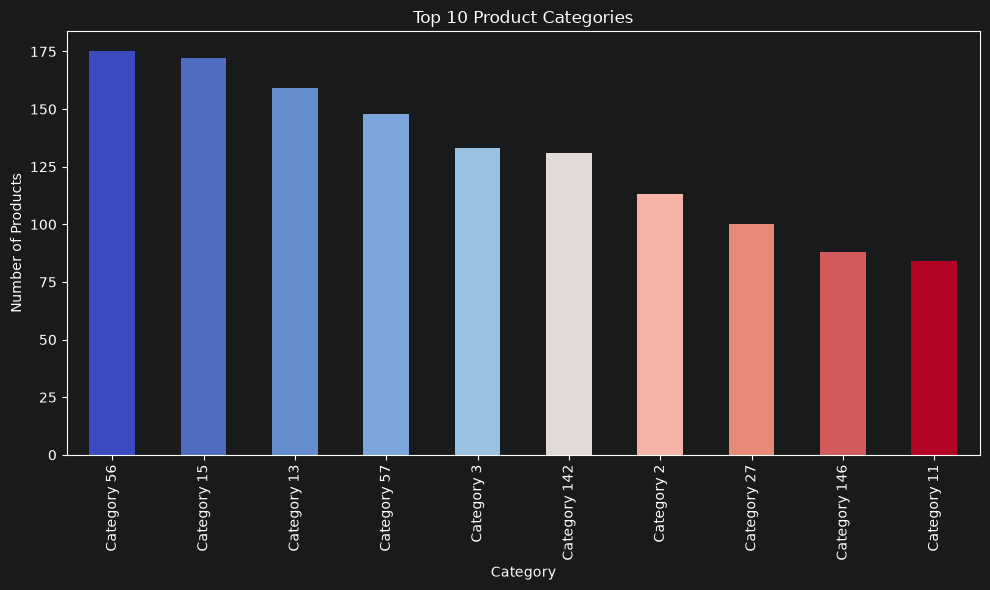

In [173]:
# Plot top 10 product categories with most number of products
top_categories = prod_df_clean['ID Product Category'].value_counts().head(10)

# Plotting
plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar', color=coolwarm_colors)
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# <a id='toc8_'></a>[Transactions Dataset](#toc0_)

## <a id='toc8_1_'></a>[Data Preprocessing](#toc0_)

In [174]:
trans_df.shape

(884099, 3)

In [175]:
trans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 884099 entries, 0 to 884098
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Date        884099 non-null  str  
 1   Client ID   884099 non-null  int64
 2   ID Product  884099 non-null  int64
dtypes: int64(2), str(1)
memory usage: 20.2 MB


In [176]:
trans_df.describe(include='all')

,Date,Client ID,ID Product
count,884099,8.840990e+05,884099.000000
unique,311,NaN,NaN
top,2022-10-01,NaN,NaN
freq,5441,NaN,NaN
mean,NaN,5.000042e+08,300857.895300
std,NaN,1.513485e+03,960.787197
min,NaN,5.000000e+08,300001.000000
25%,NaN,5.000033e+08,300185.000000
50%,NaN,5.000044e+08,300499.000000
75%,NaN,5.000056e+08,301175.000000


### <a id='toc8_1_1_'></a>[Duplicates and Missing Values](#toc0_)

#### <a id='toc8_1_1_1_'></a>[Duplicates](#toc0_)

In [177]:
# Check for duplicates
trans_df.duplicated().sum()

np.int64(9)

**Conclusion:** There are 9 duplicated rows. Further analysis needed.

In [178]:
# See all duplicates
trans_df[trans_df.duplicated(keep=False)].sort_values(by="Client ID")

,Date,Client ID,ID Product
102730,2022-03-01,500000782,300729
104615,2022-03-01,500000782,300729
105040,2022-03-01,500002145,300073
102923,2022-03-01,500002145,300073
103175,2022-03-01,500003477,300597
105329,2022-03-01,500003477,300597
105452,2022-03-01,500003606,300994
103239,2022-03-01,500003606,300994
106122,2022-03-01,500004502,300451
103627,2022-03-01,500004502,300451


**Conclusion:** Duplicates exist because same clients bought same product multiple times on the same day. This is possible and logical, we decide to create a unqiue transaction ID to differentiate between each transaction in Feature Engineering.

#### <a id='toc8_1_1_2_'></a>[Missing Values](#toc0_)

In [179]:
# Check for missing values
trans_df.isna().sum()

Date          0
Client ID     0
ID Product    0
dtype: int64

**Conclusion:** There are no missing values.

# <a id='toc9_'></a>[Feature Engineering](#toc0_)

- **1. Transaction ID**

In [180]:
# Create unique ID Transaction column
trans_df['ID Transaction'] = range(1, len(trans_df) + 1)

In [181]:
trans_df.head(5)

,Date,Client ID,ID Product,ID Transaction
0,2022-01-02,500000277,300001,1
1,2022-01-02,500000277,300002,2
2,2022-01-02,500000277,300003,3
3,2022-01-02,500000277,300004,4
4,2022-01-02,500000277,300005,5


In [182]:
# Check again for duplicates
trans_df.duplicated().sum()

np.int64(0)

- **2. Seasons of the year**

We create a column that differentiates between the seasons of the year:

In [183]:
# Ensure that the column has the correct data type
trans_df['Date'] = pd.to_datetime(trans_df['Date'])

In [184]:
# Create season column with december-february as winter, march-may as spring, june-august as summer and september-november as fall
trans_df['Season'] = trans_df['Date'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

In [185]:
# Check if it worked properly
trans_df.head()

,Date,Client ID,ID Product,ID Transaction,Season
0,2022-01-02,500000277,300001,1,Winter
1,2022-01-02,500000277,300002,2,Winter
2,2022-01-02,500000277,300003,3,Winter
3,2022-01-02,500000277,300004,4,Winter
4,2022-01-02,500000277,300005,5,Winter


# <a id='toc10_'></a>[Visualizations](#toc0_)

### <a id='toc10_1_1_'></a>[Clients with most transactions](#toc0_)

In [186]:
trans_df['Client ID'].value_counts().head(10)

Client ID
500003551    13274
500005958    12700
500003261    11438
500005337     9497
500004981     8674
500004156     7731
500004173     7212
500003578     6562
500003041     6524
500003606     5889
Name: count, dtype: int64

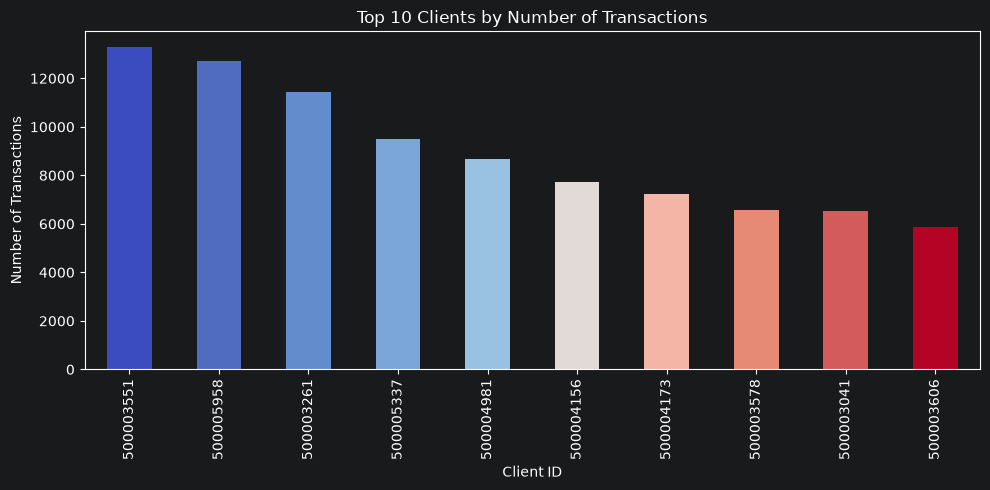

In [187]:
# Get top 10 clients by number of transactions
top_clients = trans_df['Client ID'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 5))
top_clients.plot(kind='bar', color=coolwarm_colors)
plt.title('Top 10 Clients by Number of Transactions')
plt.xlabel('Client ID')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### <a id='toc10_1_9_'></a>[Top 3 Products Purchased by Client Type](#toc0_)

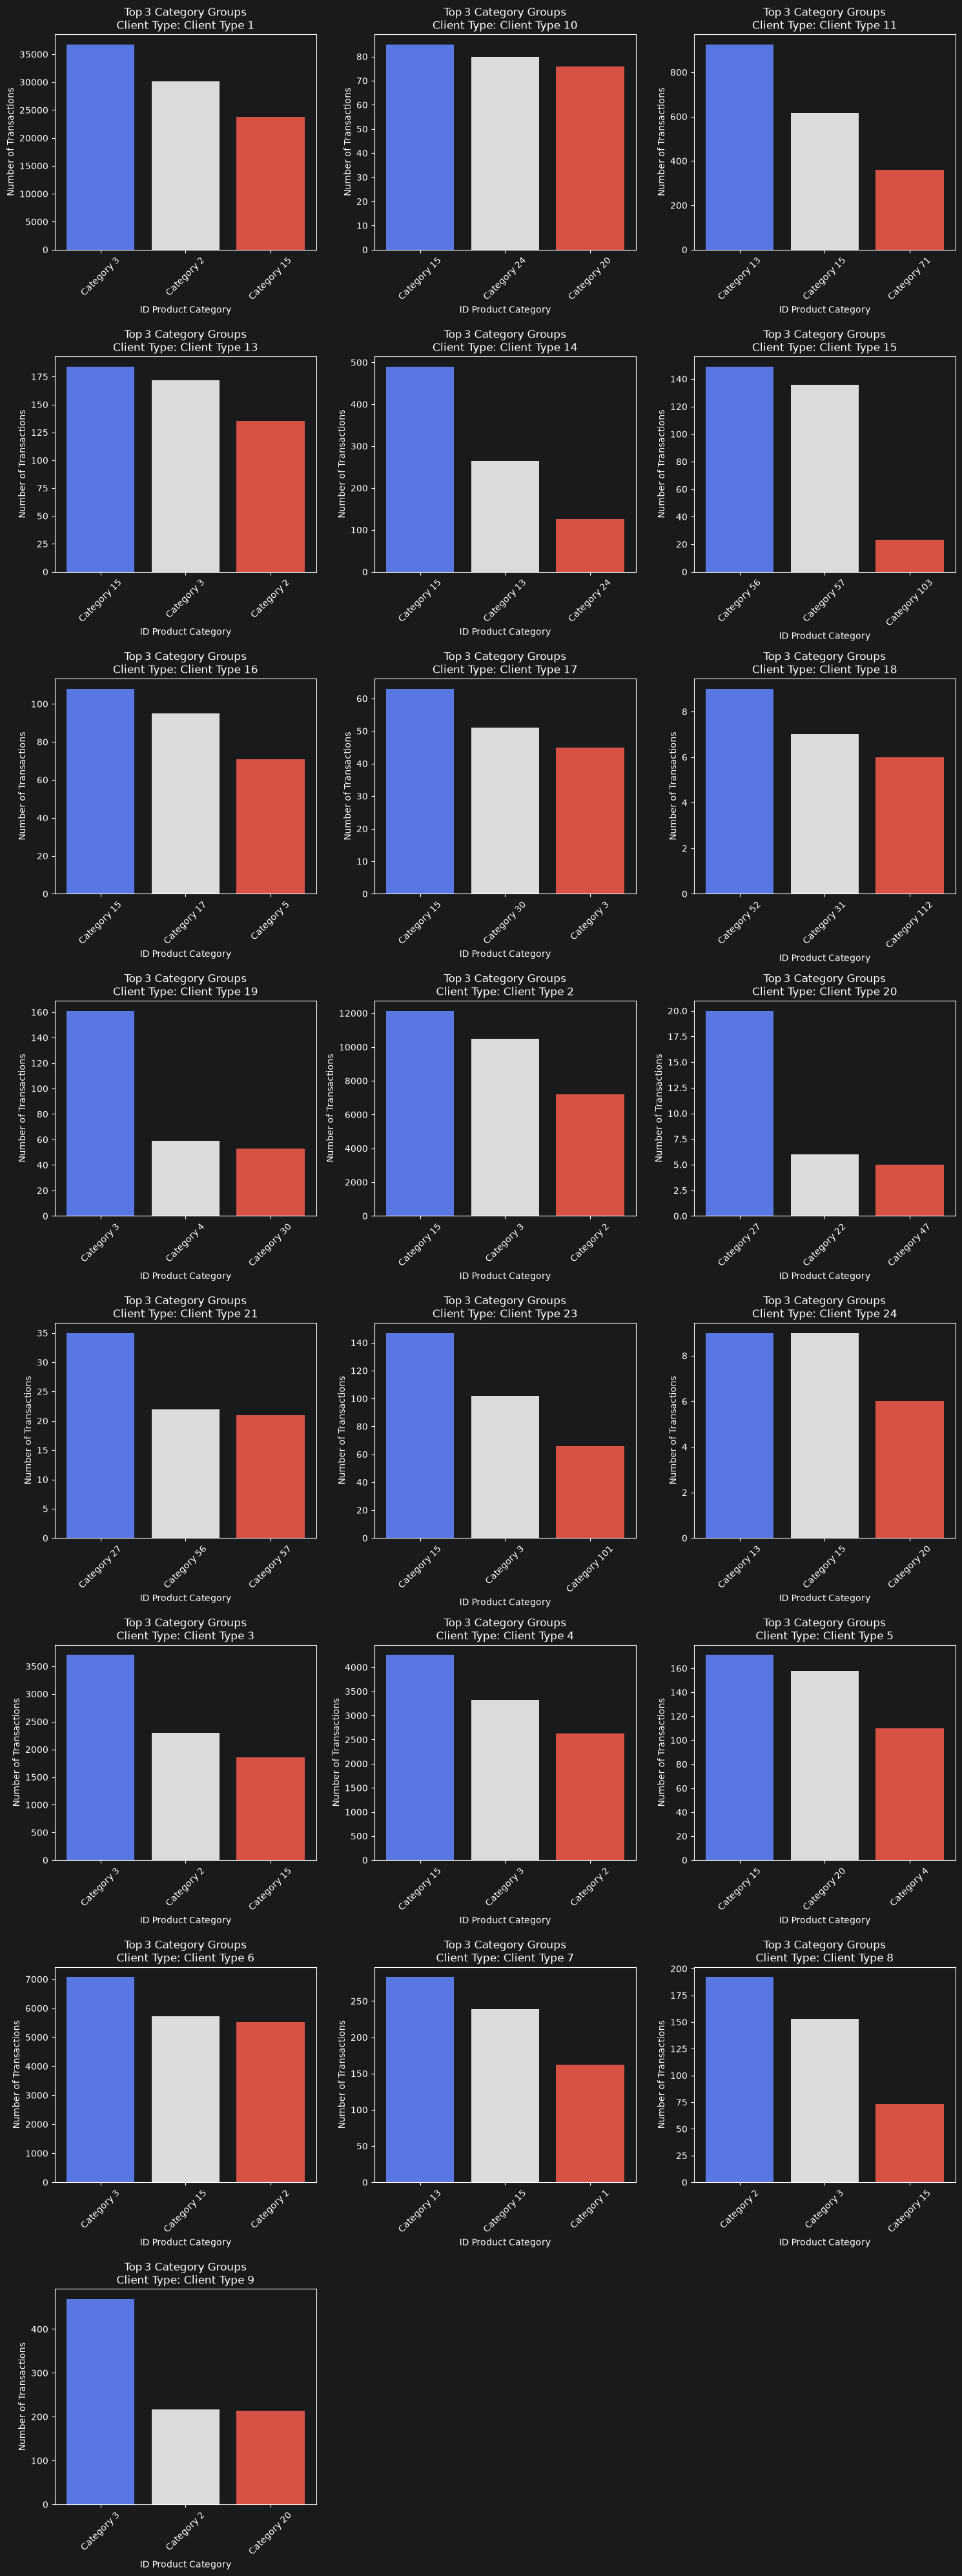

In [188]:
merged_df = (
    trans_df
        .merge(                    # First Merge
            clients_df_clean,
            left_on='Client ID',
            right_index=True,
            how='inner'
        )
        .merge(                    # Second Merge
            prod_df_clean,
            left_on='ID Product', 
            right_index=True, 
            how='inner'
        )
)

top3_per_type = (
    merged_df
      .groupby(['ID Client Type', 'ID Product Category'])
      .size()
      .reset_index(name='Count')
      .sort_values(['ID Client Type', 'Count'], ascending=[True, False])
      .groupby('ID Client Type')
      .head(3)   
)

# Unique client types
client_types = top3_per_type['ID Client Type'].unique()

# Grid layout: 3 plots per row
num_columns = 3
num_rows = (len(client_types) // num_columns) + (len(client_types) % num_columns > 0)

palette = plt.cm.coolwarm([0.1, 0.5, 0.9])

# Create the figure & axes grid
fig, axes = plt.subplots(num_rows, num_columns, figsize=(15, num_rows * 5))
axes = axes.flatten()

# Build one bar chart per client type
for i, client_type in enumerate(client_types):
    data = top3_per_type[top3_per_type['ID Client Type'] == client_type]

    axes[i].bar(data['ID Product Category'], data['Count'], color=palette)
    axes[i].set_title(
    f"Top 3 Category Groups\nClient Type: {client_type}"
)
    axes[i].set_xlabel("ID Product Category")
    axes[i].set_ylabel("Number of Transactions")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots if grid is larger than needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### <a id='toc10_1_11_'></a>[Top Best Selling Product](#toc0_)

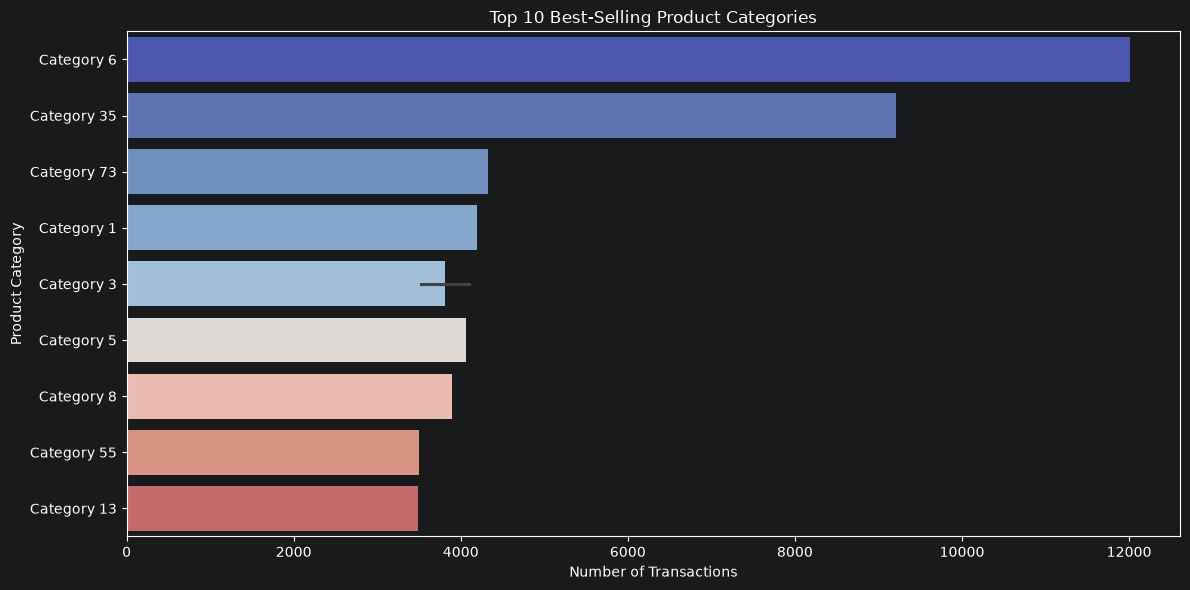

In [189]:
# 1. Count how many times each product ID appears in the transactions
product_counts = trans_df['ID Product'].value_counts().reset_index()
product_counts.columns = ['ID Product', 'count']

# 2. Merge with product data to get category information
prod_df_reset = prod_df_clean.reset_index()
merged_df = product_counts.merge(prod_df_reset[['ID Product', 'ID Product Category']], on='ID Product', how='left')

# 3. Plot the top 10 most sold products (based on transaction count)
top_n = 10
top_products = merged_df.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='count', y='ID Product Category', palette=coolwarm_colors)
plt.title(f'Top {top_n} Best-Selling Product Categories')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### <a id='toc10_1_12_'></a>[Lowest-Selling Products](#toc0_)

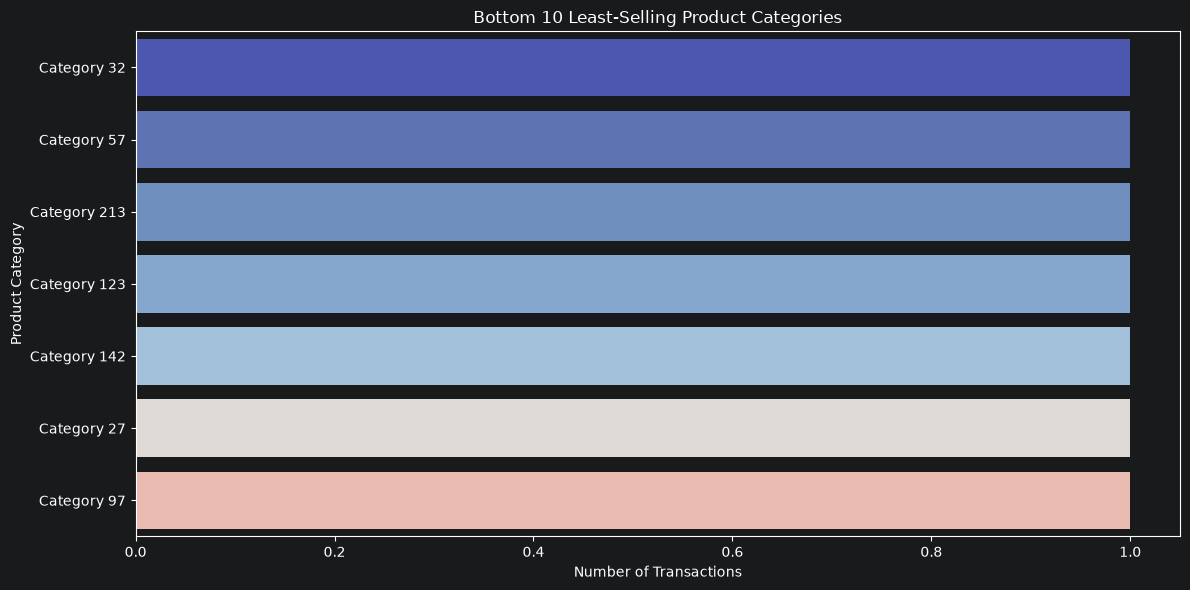

In [190]:
# 1. Count how many times each product ID appears in the transactions
product_counts = trans_df['ID Product'].value_counts().reset_index()
product_counts.columns = ['ID Product', 'count']

# 2. Merge with product data to get category information
prod_df_reset = prod_df_clean.reset_index()
merged_df = product_counts.merge(prod_df_reset[['ID Product', 'ID Product Category']], on='ID Product', how='left')

# 3. Sort by count ascending to get the lowest-selling products
bottom_n = 10
bottom_products = merged_df.sort_values(by='count', ascending=True).head(bottom_n)

# 4. Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom_products, x='count', y='ID Product Category', palette=coolwarm_colors)
plt.title(f'Bottom {bottom_n} Least-Selling Product Categories')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()